In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

reference_date = df['Order Date'].max()

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,184,5,5563.560
1,AA-10375,19,9,1056.390
2,AA-10480,259,4,1790.512
3,AA-10645,55,6,5086.935
4,AB-10015,415,3,886.156


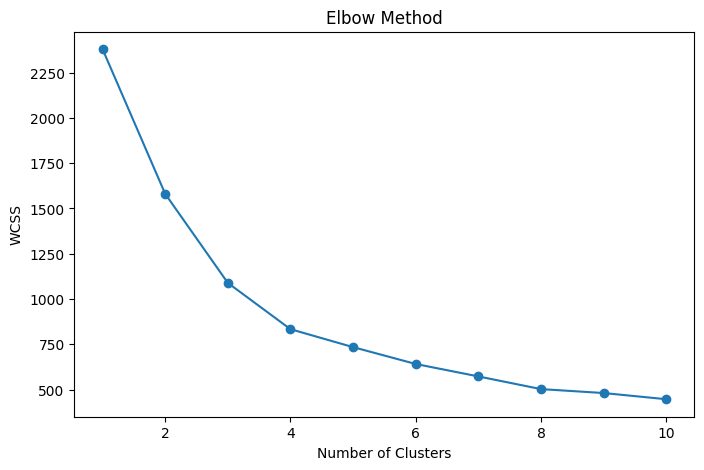

In [3]:
# Scaling (K-Means distance-based hai, isliye scaling zaroori hai)
features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Elbow method - best K dhundhne ke liye
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [4]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(scaled_features)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,AA-10315,184,5,5563.560,3
1,AA-10375,19,9,1056.390,0
2,AA-10480,259,4,1790.512,3
3,AA-10645,55,6,5086.935,0
4,AB-10015,415,3,886.156,1


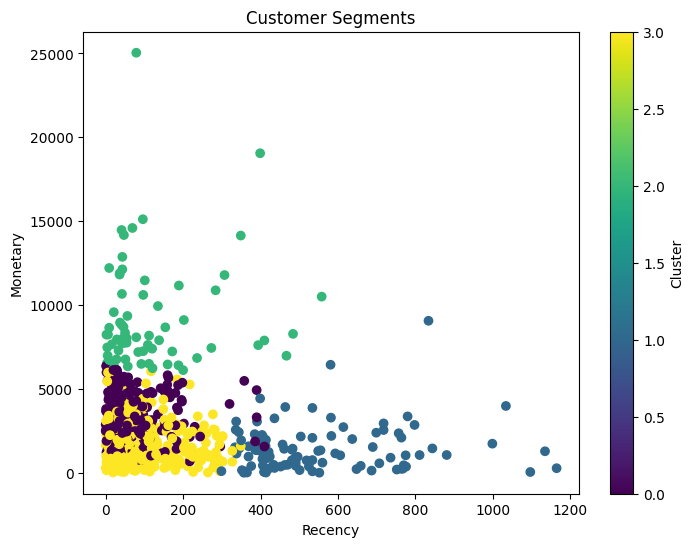

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments')
plt.colorbar(label='Cluster')
plt.show()

In [6]:
cluster_summary = rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('Cluster', 'count')
).reset_index()

cluster_summary

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Count
0,0,70.143369,8.498208,3226.843308,279
1,1,546.893204,3.708738,1432.859929,103
2,2,119.705882,8.205882,9236.454368,68
3,3,97.816327,4.696793,1707.242071,343


In [7]:
# Cluster summary dekh kar yahan mapping update karo
cluster_labels = {
    0: 'High Value Customers',
    1: 'At Risk Customers',
    2: 'New Customers',
    3: 'Regular Customers'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment
0,AA-10315,184,5,5563.560,3,Regular Customers
1,AA-10375,19,9,1056.390,0,High Value Customers
2,AA-10480,259,4,1790.512,3,Regular Customers
3,AA-10645,55,6,5086.935,0,High Value Customers
4,AB-10015,415,3,886.156,1,At Risk Customers
